# EDA

In [1]:
import os
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import numpy as np
import pandas as pd

In [2]:
CURRENT_WORKING_DIR = Path.cwd().resolve().parent

print(CURRENT_WORKING_DIR)

/home/nii/Documents/[code]sgu-2026-faical-expression-recognition


## Thống kê số lượng mỗi lớp phân loại

In [3]:
EMOTION_DICT = {
    0: "angry",
    1: "disgust",
    2: "fear",
    3: "happy",
    4: "sad",
    5: "surprise",
    6: "neutral",
}
# Màu cho từng cảm xúc
EMOTION_COLORS = {
    "angry":    "#e74c3c",
    "disgust":  "#8e44ad",
    "fear":     "#2c3e50",
    "happy":    "#f1c40f",
    "sad":      "#3498db",
    "surprise": "#e67e22",
    "neutral":  "#95a5a6",
}

In [ ]:
# note: đang dư split_name
def plot_class_distribution(csv_path: str, split_name: str = None):
    """
    Vẽ histogram phân phối số mẫu theo từng lớp cảm xúc.

    Args:
        csv_path   : đường dẫn tới file CSV (có cột 'emotion')
        split_name : tên tập dữ liệu hiển thị trên tiêu đề (vd: 'Train', 'Val', 'Test')
                     nếu None thì tự lấy từ tên file
    """
    df = pd.read_csv(csv_path)

    # Map nhãn số -> tên cảm xúc
    df["emotion_name"] = df["emotion"].map(EMOTION_DICT)

    counts = (
        df["emotion_name"]
        .value_counts()
        .reindex(EMOTION_DICT.values())   # giữ thứ tự cố định
        .fillna(0)
        .astype(int)
    )

    if split_name is None:
        split_name = os.path.splitext(os.path.basename(csv_path))[0].capitalize()

    total = counts.sum()
    colors = [EMOTION_COLORS[e] for e in counts.index]

    fig, ax = plt.subplots(figsize=(9, 6))

    bars = ax.bar(counts.index, counts.values, color=colors,
                  edgecolor="white", linewidth=0.8, width=0.65)

    # Ghi số lượng + % lên đầu mỗi cột
    for bar, val in zip(bars, counts.values):
        pct = val / total * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total * 0.005,
            f"{val:,}\n({pct:.1f}%)",
            ha="center", va="bottom",
            fontsize=8.5, color="#333333"
        )

    ax.set_title(
        f"Class Distribution — {split_name}  (total: {total:,})",
        fontsize=13, fontweight="bold", pad=14
    )
    ax.set_xlabel("Emotion", fontsize=11)
    ax.set_ylabel("Number of samples", fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.set_ylim(0, counts.max() * 1.18)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", labelsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

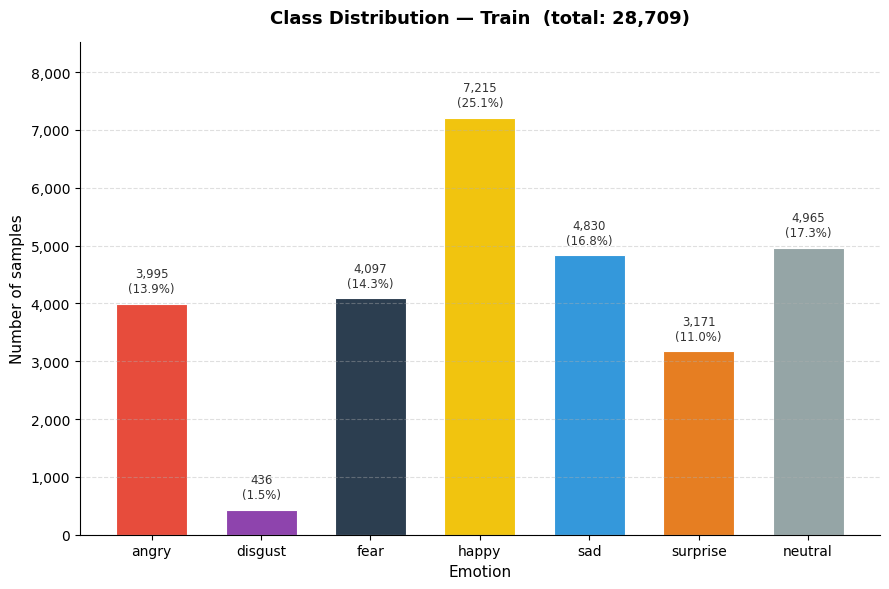

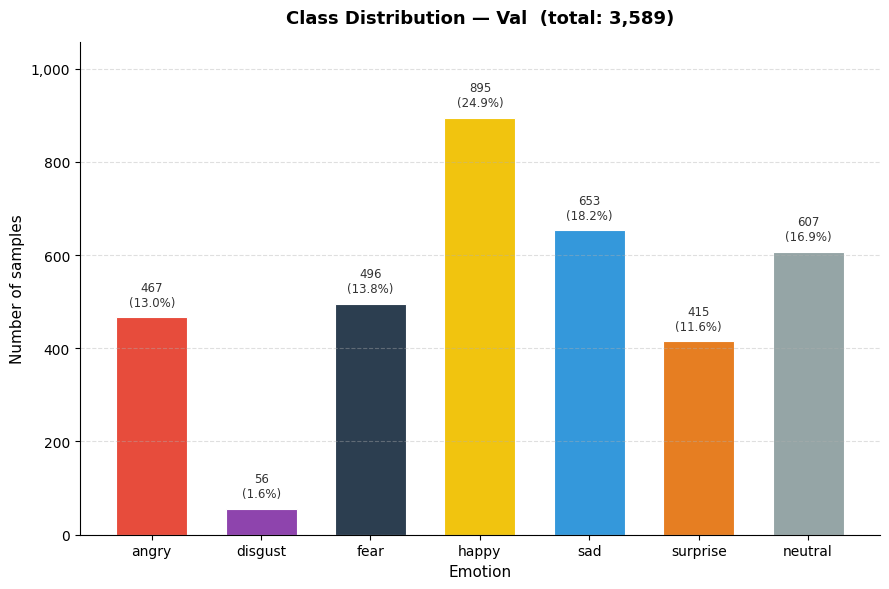

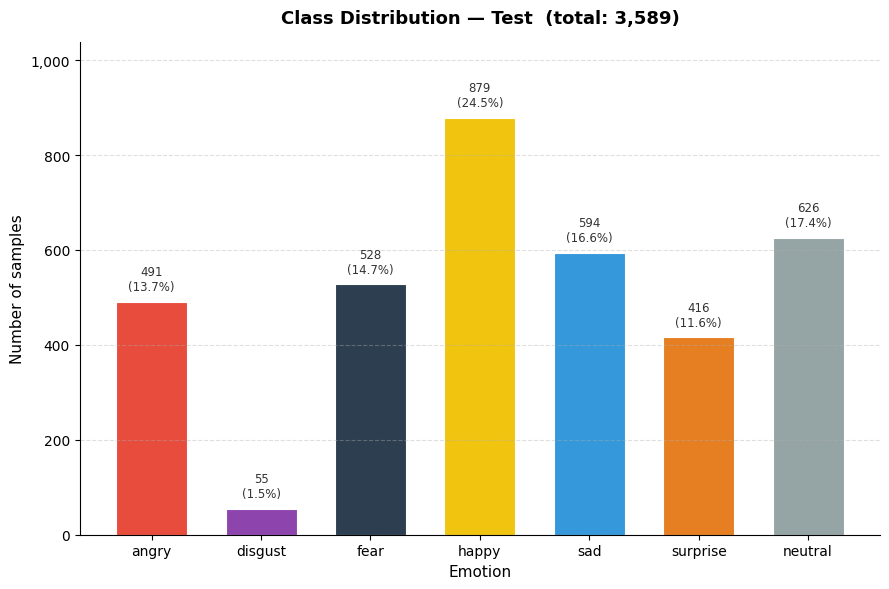

In [5]:
DATA_DIR = os.path.join(CURRENT_WORKING_DIR, "dataset/fer13-split")

TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
VAL_CSV   = os.path.join(DATA_DIR, "val.csv")
TEST_CSV  = os.path.join(DATA_DIR, "test.csv")

plot_class_distribution(TRAIN_CSV, split_name="Train")
plot_class_distribution(VAL_CSV,   split_name="Val")
plot_class_distribution(TEST_CSV,  split_name="Test")
